In [ ]:
# %reload_ext autoreload
# %autoreload 2

In [ ]:
import sys
import os
import subprocess

IN_COLAB = False
try:
  from google.colab import drive
  IN_COLAB = True
  drive.mount('/content/drive')
except:
  pass

if IN_COLAB:
  REPO_PATH = "/content/MaskArchitectureAnomaly_CourseProject"

  if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone", "https://github.com/alberto467/MaskArchitectureAnomaly_CourseProject.git", REPO_PATH],
        check=True
    )

  CWD = f"{REPO_PATH}/eomt"
else:
  CWD = "./eomt"

sys.path.insert(0, CWD)
os.chdir(CWD)

DATA_PATH = "/content/drive/MyDrive/Project-FAIMDL/downloads" if IN_COLAB else "downloads"

# Checkpoint of the Fine-Tuned model
CKPT_DIR = f"{DATA_PATH}/checkpoints/best-epoch=23-metrics"
CKPT_PATH = f"{CKPT_DIR}/val_iou_all=0.7884.ckpt"

os.makedirs(CKPT_DIR, exist_ok=True)

if not os.path.exists(CKPT_PATH):
    !gdown --id 1hO3rUgo2CpEeJt4ofid_wC9cCBdzKYbV -O "{CKPT_PATH}"

print(CKPT_PATH)
print(os.path.exists(CKPT_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Project-FAIMDL/downloads/checkpoints/best-epoch=23-metrics/val_iou_all=0.7884.ckpt
True


In [ ]:
# In Colab, just install the packages missing from the base colab packages
!pip install -r requirements.colab.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.5/443.5 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.0 M

In [ ]:
import numpy as np
import torch
from tqdm import tqdm
from dotenv import load_dotenv

load_dotenv()

# if not torch.cuda.is_available():
#     raise RuntimeError("CUDA is not available. Please check your GPU setup.")

# device = torch.device("cuda:0")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from helpers import build_data, build_model_ckpt, load_config
from helpers.inference import infer_semantic, plot_semantic_results, infer_panoptic, plot_panoptic_results
from helpers.class_remap import COMMON_CLASSES, CITY_TO_COMMON, COCO_TO_COMMON, CITY_TO_COMMON_EXP, COCO_TO_COMMON_EXP, COMMON_CLASSES_EXP

Using device: cuda:0


In [ ]:
cityscapes_config = load_config("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml")
# coco_config = load_config("configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml")
ft_config = load_config("configs/dinov2/coco_city_finetune.yaml")

In [ ]:
city_data = build_data(cityscapes_config, f"{DATA_PATH}/datasets/cityscapes")

In [ ]:
ft_model = build_model_ckpt(
    config=ft_config,
    ckpt_path=f"{DATA_PATH}/checkpoints/best-epoch=23-metrics/val_iou_all=0.7884.ckpt",
    num_classes=city_data.num_classes,
    img_size=[640, 640],
    device=device
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loaded checkpoint: /content/drive/MyDrive/Project-FAIMDL/downloads/checkpoints/best-epoch=23-metrics/val_iou_all=0.7884.ckpt
Missing keys: 0
Unexpected keys: 0


# Semantic inference

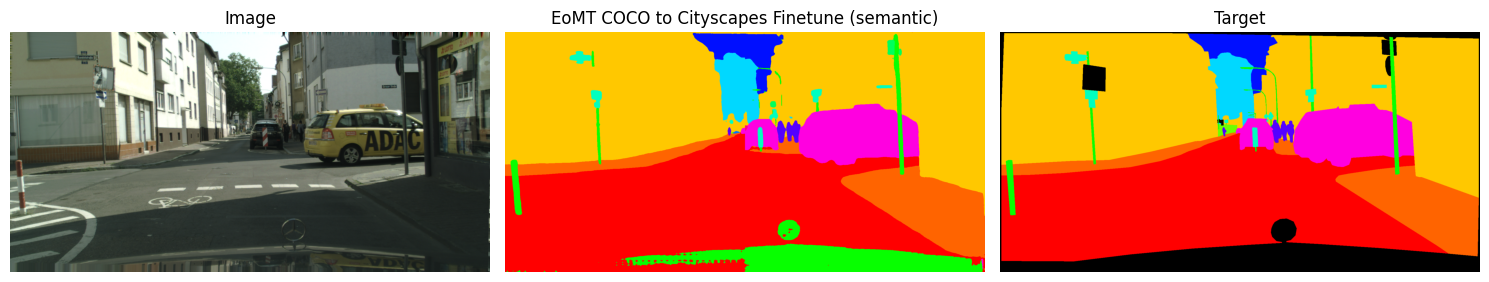

In [ ]:
img_idx = 0
img, target = city_data.val_dataloader().dataset[img_idx]
city_pred_array, city_target_array = infer_semantic(ft_model, img, target)
plot_semantic_results(img, city_pred_array, city_target_array, title="EoMT COCO to Cityscapes Finetune (semantic)")

In [ ]:
# Remap a mask from its original label space (Cityscapes or COCO) into a common label space
def remap_mask(mask, mapping, ignore_label=255):

    # Create an output mask with the same shape as input, initialized with ignore_label (default: 255)
    out = np.full_like(mask, ignore_label)
    for msk, cls in mapping.items():
        out[mask == msk] = cls  # For all pixels where mask == msk, we assign the new class id (cls)
    return out

def update_stats(tp, fp, fn, pred, target, num_classes, ignore_label=255):
    """
    Update TP, FP and FN for class evaluation.

    We evaluate only pixels whose ground truth belongs to a common class.
    If the target is common but the prediction is non-common/ignored,
    the pixel is counted as a false negative for the target class.
    """
    valid = target != ignore_label

    pred = pred[valid]
    target = target[valid]

    for c in range(num_classes):
        tp[c] += np.logical_and(pred == c, target == c).sum()
        fp[c] += np.logical_and(pred == c, target != c).sum()
        fn[c] += np.logical_and(pred != c, target == c).sum()


def compute_iou(tp, fp, fn):
    """
    Compute per-class IoU from TP, FP and FN.
    """
    denom = tp + fp + fn
    return np.where(denom == 0, np.nan, tp / denom)

In [ ]:
from helpers.class_remap import coco_classes, city_classes

idx_to_city_label = [l for _, l in city_classes]
idx_to_coco_label = [l for _, l in coco_classes]

print("Common expanded:")
common_labels_exp = {}
for city_idx, common_idx in CITY_TO_COMMON_EXP.items():
    city_label = idx_to_city_label[city_idx]
    if common_idx not in common_labels_exp:
        common_labels_exp[common_idx] = { 'city': [], 'coco': [] }
    common_labels_exp[common_idx]['city'].append(city_label)

for coco_idx, common_idx in COCO_TO_COMMON_EXP.items():
    coco_label = idx_to_coco_label[coco_idx]
    if common_idx not in common_labels_exp:
        common_labels_exp[common_idx] = { 'city': [], 'coco': [] }
    common_labels_exp[common_idx]['coco'].append(coco_label)

for common_idx, labels in common_labels_exp.items():
    city_label = labels.get('city', 'N/A')
    coco_label = labels.get('coco', 'N/A')
    print(f"Common idx {common_idx}: Cityscapes label: {city_label}, COCO label: {coco_label}")

Common expanded:
Common idx 0: Cityscapes label: ['road'], COCO label: ['road']
Common idx 1: Cityscapes label: ['sidewalk'], COCO label: ['pavement-merged']
Common idx 2: Cityscapes label: ['building'], COCO label: ['building-other-merged', 'house', 'roof']
Common idx 3: Cityscapes label: ['wall'], COCO label: ['wall-brick', 'wall-stone', 'wall-tile', 'wall-wood', 'wall-other-merged']
Common idx 4: Cityscapes label: ['fence'], COCO label: ['fence-merged']
Common idx 5: Cityscapes label: ['traffic light'], COCO label: ['traffic light']
Common idx 6: Cityscapes label: ['traffic sign'], COCO label: ['stop sign']
Common idx 7: Cityscapes label: ['vegetation'], COCO label: ['tree-merged', 'grass-merged', 'flower']
Common idx 8: Cityscapes label: ['terrain'], COCO label: ['sand', 'dirt-merged', 'gravel', 'platform', 'playingfield', 'snow']
Common idx 9: Cityscapes label: ['sky'], COCO label: ['sky-other-merged']
Common idx 10: Cityscapes label: ['person'], COCO label: ['person']
Common idx 

# Common-Class Evaluation pipeline

In [ ]:
from tqdm import tqdm  # debug

IGNORE_EVAL = 255                 # label to ignore pixels
num_common = len(COMMON_CLASSES)  # number of classes in the common evaluation space
num_common_exp = len(COMMON_CLASSES_EXP)  # number of classes in the common evaluation space
num_city_classes = city_data.num_classes

# Stats for COMMON classes
tp_ft = np.zeros(num_common, dtype=np.int64)
fp_ft = np.zeros(num_common, dtype=np.int64)
fn_ft = np.zeros(num_common, dtype=np.int64)

# Stats for EXPANDED classes
tp_ft_exp = np.zeros(num_common_exp, dtype=np.int64)
fp_ft_exp = np.zeros(num_common_exp, dtype=np.int64)
fn_ft_exp = np.zeros(num_common_exp, dtype=np.int64)

# Stats for ALL Cityscapes classes
tp_ft_full = np.zeros(num_city_classes, dtype=np.int64)
fp_ft_full = np.zeros(num_city_classes, dtype=np.int64)
fn_ft_full = np.zeros(num_city_classes, dtype=np.int64)


# Dataset: validation split from Cityscapes
val_dataset = city_data.val_dataloader().dataset

for idx in tqdm(range(len(val_dataset))):

    img, target = val_dataset[idx]

    # STEP 1: Run inference
    # --------------------------------------------------------
    # Finetuned model -> semantic inference
    pred_ft_raw, target_ft_raw = infer_semantic(ft_model, img, target)


    # STEP 2: Remap predictions and targets to common space
    # --------------------------------------------------------
    # Remap to COMMON classes
    target_common = remap_mask(target_ft_raw, CITY_TO_COMMON, ignore_label=IGNORE_EVAL)
    pred_ft_common = remap_mask(pred_ft_raw, CITY_TO_COMMON, ignore_label=IGNORE_EVAL)

    # Remap to EXPANDED classes
    target_common_exp = remap_mask(target_ft_raw, CITY_TO_COMMON_EXP, ignore_label=IGNORE_EVAL)
    pred_ft_common_exp = remap_mask(pred_ft_raw, CITY_TO_COMMON_EXP, ignore_label=IGNORE_EVAL)

    # Full Cityscapes classes
    target_full = target_ft_raw
    pred_ft_full = pred_ft_raw

    # STEP 3: Update statistics
    # --------------------------------------------------------
    # Update confusion matrices
    update_stats(tp_ft, fp_ft, fn_ft, pred_ft_common, target_common, num_common, IGNORE_EVAL)
    update_stats(tp_ft_exp, fp_ft_exp, fn_ft_exp, pred_ft_common_exp, target_common_exp, num_common_exp, IGNORE_EVAL)
    update_stats(tp_ft_full, fp_ft_full, fn_ft_full, pred_ft_full, target_full, num_city_classes, IGNORE_EVAL)

# COMPUTE IoU AND mIoU
ious_ft = compute_iou(tp_ft, fp_ft, fn_ft)
ious_ft_exp = compute_iou(tp_ft_exp, fp_ft_exp, fn_ft_exp)
ious_ft_full = compute_iou(tp_ft_full, fp_ft_full, fn_ft_full)

miou_ft = np.nanmean(ious_ft)
miou_ft_exp = np.nanmean(ious_ft_exp)
miou_ft_full = np.nanmean(ious_ft_full)

print("\n=== Common-class semantic evaluation on Cityscapes val ===")
print("Common classes:", COMMON_CLASSES)

print("\nPer-class IoU (Finetuned model)")
for name, v in zip(COMMON_CLASSES, ious_ft):
    print(f"{name:12s}: {v:.4f}")
print(f"mIoU: {miou_ft:.4f}\n")

print("\n=== Common-class-Expanded semantic evaluation on Cityscapes val ===")
print("Common classes expanded:", COMMON_CLASSES_EXP)

print("\nPer-class IoU (Finetuned model)")
for name, v in zip(COMMON_CLASSES_EXP, ious_ft_exp):
    print(f"{name:12s}: {v:.4f}")
print(f"mIoU: {miou_ft_exp:.4f}")



CITYSCAPES_CLASSES = [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle"
]

print("\n=== All-Cityscapes-class semantic evaluation on Cityscapes val ===")
print("\nAll Cityscapes classes:", CITYSCAPES_CLASSES)

print("\nPer-class IoU (Finetuned model)")
for name, v in zip(CITYSCAPES_CLASSES, ious_ft_full):
    print(f"{name:15s}: {v:.4f}")

print(f"mIoU: {miou_ft_full:.4f}")

100%|██████████| 500/500 [07:50<00:00,  1.06it/s]


=== Common-class semantic evaluation on Cityscapes val ===
Common classes: ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'train', 'truck', 'traffic light']

Per-class IoU (Finetuned model)
person      : 0.8995
bicycle     : 0.8617
car         : 0.9697
motorcycle  : 0.7226
bus         : 0.8815
train       : 0.6988
truck       : 0.8509
traffic light: 0.8340
mIoU: 0.8398

Common classes expanded: ['road', 'sidewalk', 'building', 'wall', 'fence', 'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky', 'person', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle']

Per-class IoU (Finetuned model)
road        : 0.9822
sidewalk    : 0.8633
building    : 0.9377
wall        : 0.6342
fence       : 0.6683
traffic light: 0.7367
traffic sign: 0.7866
vegetation  : 0.9287
terrain     : 0.6961
sky         : 0.9504
person      : 0.8419
car         : 0.9520
truck       : 0.8308
bus         : 0.8574
train       : 0.6850
motorcycle  : 0.6734
bicycle     : 0.8018
mIoU: 0.8133
All Cityscap